# Tutorial 5: ANN
- Dataset: dataset/Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx
- ANN: Artificial Neural Networks

### Tasks:
- Finding out best hyperparameters for ANN
- Training ANN with the best hyperparameters
- Evaluating the performance of ANN
- Parametric Analysis
- Bin residual plots
- SHAP analysis and feature importance

### Inputs:
- Earth Magnitude
- Joyner-Boore Dist. (km)
- Mechanism Based on Rake Angle 
- Vs30 (m/s) selected for analysis
- Log10 of Vs30 (m/s)
- Log10 of Joyner-Boore Dist. (km)

### Outputs:
- Log10(PGV (cm/sec))
- Log10(PGA (g))
- Log10 of Spectral Acceleration from 0.01s to 4s: (T0.010S - T4.00S)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import time
import copy

print(f"✓ PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")

✓ PyTorch version: 2.6.0+cu124
✓ Device: cuda


In [2]:
import importlib.util
import subprocess
import sys

# Dictionary mapping the 'import' name to the 'pip install' name
dependencies = {
    'shap': 'shap',
    'calamine': 'python-calamine'
    # Add any other weird dependencies from your requirements.txt here!
}

for module, package in dependencies.items():
    # Check if the module is already installed
    if importlib.util.find_spec(module) is None:
        print(f"📦 {package} not found. Installing...")
        # Runs: pip install -q package_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    else:
        print(f"✅ {package} is already installed.")

✅ shap is already installed.
📦 python-calamine not found. Installing...


In [ ]:
import glob

# 1. Exact paths for Kaggle cloud vs your local WSL environment
FILENAME    = 'Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx'
kaggle_path = f'/kaggle/input/nga-west2-seismic-data/{FILENAME}'
local_path  = f'dataset/{FILENAME}'

# 2. Automatically detect the environment
if os.path.exists('/kaggle/input'):
    print("☁️ Running on Kaggle!")

    if os.path.exists(kaggle_path):
        file_path = kaggle_path
        print(f"✅ Found dataset at expected path: {file_path}")
    else:
        matches = [m for m in glob.glob('/kaggle/input/**/*.xlsx', recursive=True)
                   if FILENAME in m]
        if matches:
            file_path = matches[0]
            print(f"✅ Found dataset (auto-discovered): {file_path}")
        else:
            print("\n❌ Dataset NOT found under /kaggle/input/")
            print("   Available inputs:", os.listdir('/kaggle/input') or "(empty)")
            raise FileNotFoundError(
                "\n\nTo fix this, attach the dataset to your notebook:\n"
                "  1. Open this notebook on Kaggle\n"
                "  2. Right panel → 'Input' tab → '+ Add Input'\n"
                "  3. Search for 'nga-west2-seismic-data' (or 'premsuggu11/nga-west2-seismic-data')\n"
                "  4. Click 'Add' then re-run all cells\n"
            )
else:
    print("💻 Running locally! Using local dataset path.")
    file_path = local_path

# 3. Load the data using the calamine engine
try:
    test_df = pd.read_excel(file_path, nrows=1, engine='calamine')
    print("✅ Columns loaded successfully:", len(test_df.columns), "columns")
except FileNotFoundError:
    print(f"❌ ERROR: Could not find the file at {file_path}")

In [4]:
len(test_df.columns)

274

In [5]:
# Helper function to convert period column name to float
def period_to_float(col_name):
    """Convert column name like T0.010S to 0.010"""
    return float(col_name[1:-1])

# Get all column names first
print("Reading column names...")
df_temp = pd.read_excel(file_path, engine='calamine', nrows=0)
all_cols = df_temp.columns.tolist()

# Find period columns <= 4.0 seconds only
period_cols = [col for col in all_cols if col.startswith('T') and col.endswith('S')]
selected_period_cols = [col for col in period_cols if period_to_float(col) <= 4.0]
selected_period_cols_sorted = sorted(selected_period_cols, key=period_to_float)

# Define columns to load
selected_columns = [
    'Earthquake Magnitude',
    'Joyner-Boore Dist. (km)',
    'Vs30 (m/s) selected for analysis',
    'Mechanism Based on Rake Angle',
    'PGA (g)',
    'PGV (cm/sec)'
] + selected_period_cols_sorted

# Define dtypes for faster loading
dtype_dict = {
    'Earthquake Magnitude': 'float32',
    'Joyner-Boore Dist. (km)': 'float32',
    'Vs30 (m/s) selected for analysis': 'float32',
    'Mechanism Based on Rake Angle': 'int8',
    'PGA (g)': 'float32',
    'PGV (cm/sec)': 'float32'
}
for col in selected_period_cols_sorted:
    dtype_dict[col] = 'float32'

print(f"Loading {len(selected_columns)} columns (6 base features + {len(selected_period_cols_sorted)} periods)...")
print(f"Period range: {period_to_float(selected_period_cols_sorted[0]):.3f}s to {period_to_float(selected_period_cols_sorted[-1]):.3f}s")

# Load data
df = pd.read_excel(file_path, engine='calamine', usecols=selected_columns, dtype=dtype_dict)

print(f"✓ Loaded data shape: {df.shape}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Reading column names...
Loading 96 columns (6 base features + 90 periods)...
Period range: 0.010s to 4.000s
✓ Loaded data shape: (21540, 96)
  Memory usage: 7.83 MB


In [6]:
# Data Cleaning: Remove rows with negative, NaN, or Inf values
print("=" * 70)
print("DATA CLEANING")
print("=" * 70)
print(f"\nOriginal shape: {df.shape}")

cols_to_check = [
    'Earthquake Magnitude',
    'Joyner-Boore Dist. (km)',
    'Vs30 (m/s) selected for analysis',
    'Mechanism Based on Rake Angle',
    'PGA (g)',
    'PGV (cm/sec)'
] + selected_period_cols_sorted

# Step 1: Remove rows with any negative values
print("\nRemoving rows with negative values...")
before = len(df)
for col in cols_to_check:
    df = df[df[col] >= 0]
print(f"  After removing negatives: {len(df):,} rows (removed {before - len(df):,})")

# Step 2: Drop NaN / Inf rows
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=cols_to_check)
print(f"  After dropping NaN/Inf:   {len(df):,} rows (removed {before - len(df):,})")

df = df.reset_index(drop=True)

print(f"\n✓ Final cleaned shape: {df.shape}")
print(f"\nData ranges:")
print(f"  Earthquake Magnitude:          {df['Earthquake Magnitude'].min():.2f} – {df['Earthquake Magnitude'].max():.2f}")
print(f"  Joyner-Boore Dist. (km):       {df['Joyner-Boore Dist. (km)'].min():.3f} – {df['Joyner-Boore Dist. (km)'].max():.2f}")
print(f"  Vs30 (m/s):                    {df['Vs30 (m/s) selected for analysis'].min():.1f} – {df['Vs30 (m/s) selected for analysis'].max():.1f}")
print(f"  Mechanism Based on Rake Angle: {sorted(df['Mechanism Based on Rake Angle'].unique())}")
print(f"  PGA (g):                       {df['PGA (g)'].min():.6f} – {df['PGA (g)'].max():.4f}")
print(f"  PGV (cm/sec):                  {df['PGV (cm/sec)'].min():.6f} – {df['PGV (cm/sec)'].max():.4f}")
print("=" * 70)


DATA CLEANING

Original shape: (21540, 96)

Removing rows with negative values...
  After removing negatives: 21,293 rows (removed 247)
  After dropping NaN/Inf:   21,293 rows (removed 0)

✓ Final cleaned shape: (21293, 96)

Data ranges:
  Earthquake Magnitude:          2.99 – 7.90
  Joyner-Boore Dist. (km):       0.000 – 1532.66
  Vs30 (m/s):                    89.3 – 2100.0
  Mechanism Based on Rake Angle: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]
  PGA (g):                       0.000000 – 1.7683
  PGV (cm/sec):                  0.000007 – 256.6200


In [7]:
# Log-transform features and targets, then define input/output columns
print("=" * 70)
print("PREPROCESSING")
print("=" * 70)

df = df.reset_index(drop=True)

# Log10-transformed inputs
df['log10_Rjb']  = np.log10(df['Joyner-Boore Dist. (km)'])
df['log10_Vs30'] = np.log10(df['Vs30 (m/s) selected for analysis'])

# Log10-transformed targets
df['log10_PGA'] = np.log10(df['PGA (g)'])
df['log10_PGV'] = np.log10(df['PGV (cm/sec)'])

print("Creating log10 of spectral periods...")
for col in tqdm(selected_period_cols_sorted, desc="Log-transforming Sa"):
    df[f'log10_{col}'] = np.log10(df[col])

# Column lists used downstream
input_feature_cols = [
    'Earthquake Magnitude',
    'Joyner-Boore Dist. (km)',
    'Mechanism Based on Rake Angle',
    'Vs30 (m/s) selected for analysis',
    'log10_Vs30',
    'log10_Rjb'
]
output_target_cols = (
    ['log10_PGA', 'log10_PGV'] +
    [f'log10_{col}' for col in selected_period_cols_sorted]
)

# Sanity check: no inf/nan in transformed columns
all_transformed = ['log10_Rjb', 'log10_Vs30', 'log10_PGA', 'log10_PGV'] + \
                  [f'log10_{col}' for col in selected_period_cols_sorted]
invalid = df[all_transformed].replace([np.inf, -np.inf], np.nan).isna().any(axis=1).sum()
if invalid:
    print(f"  ⚠ Dropping {invalid} rows with inf/nan after log transform")
    df = df[~df[all_transformed].replace([np.inf, -np.inf], np.nan).isna().any(axis=1)]
    df = df.reset_index(drop=True)
else:
    print("  ✓ All log-transformed values are finite")

print(f"\nFinal dataset: {len(df):,} samples")
print(f"\nInputs  ({len(input_feature_cols)}): {input_feature_cols}")
print(f"Outputs ({len(output_target_cols)}): log10_PGA, log10_PGV + {len(selected_period_cols_sorted)} Sa periods")
print("=" * 70)


/home/prem/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


PREPROCESSING
Creating log10 of spectral periods...


Log-transforming Sa: 100%|██████████| 90/90 [00:00<00:00, 1315.93it/s]

  ⚠ Dropping 63 rows with inf/nan after log transform

Final dataset: 21,230 samples

Inputs  (6): ['Earthquake Magnitude', 'Joyner-Boore Dist. (km)', 'Mechanism Based on Rake Angle', 'Vs30 (m/s) selected for analysis', 'log10_Vs30', 'log10_Rjb']
Outputs (92): log10_PGA, log10_PGV + 90 Sa periods


In [8]:
# Single Hidden Layer ANN for Ground Motion Prediction
class ANNModel(nn.Module):
    """
    Single-hidden-layer ANN for Ground Motion Prediction.

    Architecture:
        Input (6) → Hidden (N, ReLU) → Dropout → Output (PGA + PGV + Sa periods)

    Parameters
    ----------
    input_dim     : number of input features (6)
    output_dim    : number of outputs  (PGA + PGV + Sa periods)
    hidden_neurons: neurons in the single hidden layer
    dropout_rate  : dropout probability (0.0 = disabled)
    """
    def __init__(self, input_dim, output_dim, hidden_neurons=30, dropout_rate=0.0):
        super(ANNModel, self).__init__()
        self.hidden1  = nn.Linear(input_dim, hidden_neurons)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.output   = nn.Linear(hidden_neurons, output_dim)
        self.relu     = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.dropout1(x)
        x = self.output(x)          # linear activation for regression
        return x


def create_ann_model(input_dim, output_dim, hidden_neurons=30,
                     learning_rate=0.001, dropout_rate=0.0):
    """Instantiate model, Adam optimizer, and MSELoss."""
    model     = ANNModel(input_dim, output_dim, hidden_neurons, dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    return model, optimizer, criterion


# Quick architecture summary
input_dim  = len(input_feature_cols)
output_dim = len(output_target_cols)

dummy_model = ANNModel(input_dim, output_dim, hidden_neurons=30)
total_params = sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)

print("=" * 70)
print("MODEL ARCHITECTURE  (Single Hidden Layer ANN)")
print("=" * 70)
print(f"  Input  layer : {input_dim}  features")
print(f"  Hidden layer : 30 neurons  (ReLU + Dropout)")
print(f"  Output layer : {output_dim} outputs  (log10_PGA + log10_PGV + {len(selected_period_cols_sorted)} Sa)")
print(f"\n  Trainable parameters (30-neuron config): {total_params:,}")
print(f"\n{dummy_model}")
print("=" * 70)

MODEL ARCHITECTURE  (Single Hidden Layer ANN)
  Input  layer : 6  features
  Hidden layer : 30 neurons  (ReLU + Dropout)
  Output layer : 92 outputs  (log10_PGA + log10_PGV + 90 Sa)

  Trainable parameters (30-neuron config): 3,062

ANNModel(
  (hidden1): Linear(in_features=6, out_features=30, bias=True)
  (dropout1): Dropout(p=0.0, inplace=False)
  (output): Linear(in_features=30, out_features=92, bias=True)
  (relu): ReLU()
)


In [9]:
# Train / Test split + StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[input_feature_cols].values.astype('float32')
y = df[output_target_cols].values.astype('float32')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_scaled,  dtype=torch.float32)

print(f"Train : {X_train_scaled.shape[0]:,} samples")
print(f"Test  : {X_test_scaled.shape[0]:,}  samples")
print(f"X shape: {X_train_scaled.shape}  |  y shape: {y_train_scaled.shape}")


Train : 16,984 samples
Test  : 4,246  samples
X shape: (16984, 6)  |  y shape: (16984, 92)


In [10]:
# ── Helper functions ──────────────────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)
OUTPUT_DIR = 'results/5'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def make_loaders(X_tr, y_tr, batch_size, val_frac=0.2, seed=42):
    """Split train set → train/val DataLoaders."""
    dataset = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                            torch.tensor(y_tr, dtype=torch.float32))
    n_val   = int(len(dataset) * val_frac)
    n_train = len(dataset) - n_val
    g       = torch.Generator().manual_seed(seed)
    tr_sub, val_sub = torch.utils.data.random_split(dataset, [n_train, n_val], generator=g)
    return (DataLoader(tr_sub,  batch_size=batch_size, shuffle=True),
            DataLoader(val_sub, batch_size=batch_size, shuffle=False))


def train_with_early_stopping(model, optimizer, criterion,
                              train_loader, val_loader,
                              max_epochs=100, patience=10):
    """Train with early stopping; returns (best_val_loss, best_train_loss, epochs_trained)."""
    best_val   = float('inf')
    best_train = float('inf')
    counter    = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        avg_train = float(np.mean(train_losses))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                val_losses.append(criterion(model(Xb.to(device)), yb.to(device)).item())
        avg_val = float(np.mean(val_losses))

        if avg_val < best_val:
            best_val   = avg_val
            best_train = avg_train
            counter    = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                break

    model.load_state_dict(best_state)
    return best_val, best_train, epoch + 1


def get_predictions(model, X_tensor, batch_size=2048):
    """Run inference in batches; returns numpy array."""
    model.eval()
    preds = []
    with torch.no_grad():
        for (Xb,) in DataLoader(TensorDataset(X_tensor), batch_size=batch_size):
            preds.append(model(Xb.to(device)).cpu().numpy())
    return np.vstack(preds)


def zoomed_dual_plot(results, x_key, x_label, title, x_ticks=None,
                     log_x=False, filename=None):
    """
    Two side-by-side zoomed plots: Training MSE Loss (left) and Validation MSE
    Loss (right).  Y-axis is auto-zoomed to the actual data range + 30% padding
    so small differences become clearly visible.
    """
    xs       = [r[x_key]        for r in results]
    val_vals = [r['val_loss']   for r in results]
    tr_vals  = [r['train_loss'] for r in results]
    best_x   = results[int(np.argmin(val_vals))][x_key]

    def zoomed_ax(ax, ys, ylabel, color, marker):
        ax.plot(xs, ys, marker=marker, linewidth=2.5, markersize=9,
                color=color, zorder=3)
        ax.scatter([best_x], [ys[xs.index(best_x)]], s=300, c='gold',
                   marker='*', edgecolors='black', linewidth=1.5, zorder=5,
                   label=f'Best: {best_x}')
        pad = max((max(ys) - min(ys)) * 0.35, abs(np.mean(ys)) * 1e-4)
        ax.set_ylim(min(ys) - pad, max(ys) + pad)
        ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
        ax.set_xlabel(x_label, fontsize=13, fontweight='bold')
        if log_x:
            ax.set_xscale('log')
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    zoomed_ax(ax1, tr_vals,  'Train MSE Loss (zoomed)', '#3498DB', 'o')
    zoomed_ax(ax2, val_vals, 'Val   MSE Loss (zoomed)', '#E74C3C', 's')
    ax1.set_title('Training Loss', fontsize=12, fontweight='bold')
    ax2.set_title('Validation Loss', fontsize=12, fontweight='bold')
    plt.tight_layout()
    if filename:
        plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {OUTPUT_DIR}/{filename}")
    plt.show()


print("✓ Helper functions defined")
print(f"✓ Output dir: {OUTPUT_DIR}")

✓ Helper functions defined
✓ Output dir: results/5


STEP 1: HIDDEN SIZE SEARCH
Fixed → lr=0.001, batch_size=64, max_epochs=100, patience=10


Hidden size search:   0%|          | 0/5 [00:00<?, ?it/s]

Hidden size search:  20%|██        | 1/5 [00:40<02:43, 40.90s/it]

  hidden=15  train_loss=0.102970  val_loss=0.103428  epochs=100


Hidden size search:  40%|████      | 2/5 [01:18<01:56, 38.79s/it]

...

Hidden size search:  80%|████████  | 4/5 [02:28<00:36, 36.58s/it]

  hidden=30  train_loss=0.100496  val_loss=0.100735  epochs=100


Hidden size search: 100%|██████████| 5/5 [03:05<00:00, 37.10s/it]

  hidden=35  train_loss=0.099601  val_loss=0.101001  epochs=100

✓ Best hidden size: 30  (val_loss=0.100735)


✓ Saved: results/5/search_hidden_size.png


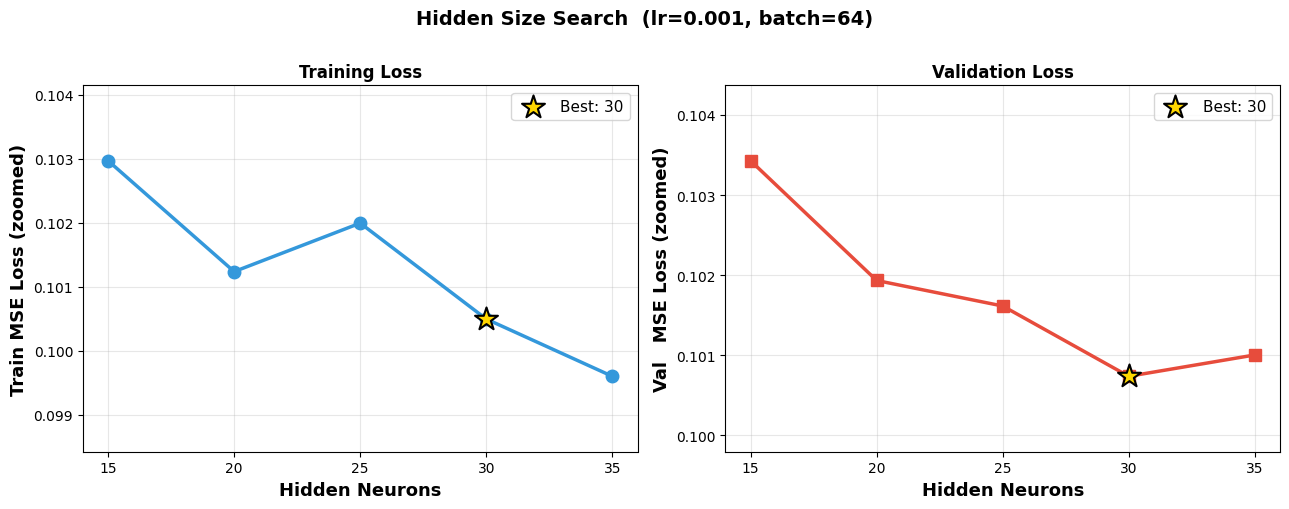

In [11]:
# ── Step 1: Search Hidden Size ────────────────────────────────────────────────
# Fixed: lr=0.001, batch_size=64
print("=" * 70)
print("STEP 1: HIDDEN SIZE SEARCH")
print("=" * 70)
print("Fixed → lr=0.001, batch_size=64, max_epochs=100, patience=10")

hidden_sizes = [15, 20, 25, 30, 35]
FIXED_LR_HS  = 0.001
FIXED_BS_HS  = 64

train_loader_hs, val_loader_hs = make_loaders(X_train_scaled, y_train_scaled, FIXED_BS_HS)

hs_results = []
for hs in tqdm(hidden_sizes, desc="Hidden size search"):
    model, opt, crit = create_ann_model(input_dim, output_dim,
                                        hidden_neurons=hs, learning_rate=FIXED_LR_HS)
    best_val, best_train, epochs = train_with_early_stopping(
        model, opt, crit, train_loader_hs, val_loader_hs, max_epochs=100, patience=10)
    hs_results.append({'hidden_size': hs, 'val_loss': best_val,
                       'train_loss': best_train, 'epochs': epochs})
    print(f"  hidden={hs:2d}  train_loss={best_train:.6f}  val_loss={best_val:.6f}  epochs={epochs}")

best_hs      = min(hs_results, key=lambda r: r['val_loss'])['hidden_size']
best_hs_loss = min(hs_results, key=lambda r: r['val_loss'])['val_loss']
print(f"\n✓ Best hidden size: {best_hs}  (val_loss={best_hs_loss:.6f})")

zoomed_dual_plot(hs_results, 'hidden_size', 'Hidden Neurons',
                 f'Hidden Size Search  (lr={FIXED_LR_HS}, batch={FIXED_BS_HS})',
                 x_ticks=[r['hidden_size'] for r in hs_results],
                 filename='search_hidden_size.png')


STEP 2: BATCH SIZE SEARCH
Fixed → hidden=30, lr=0.001, max_epochs=100, patience=10


Batch size search:  25%|██▌       | 1/4 [01:13<03:41, 73.79s/it]

  batch= 16  train_loss=0.101184  val_loss=0.100224  epochs=54


Batch size search:  50%|█████     | 2/4 [02:10<02:07, 63.76s/it]

  batch= 32  train_loss=0.100130  val_loss=0.099927  epochs=82


Batch size search:  75%|███████▌  | 3/4 [02:50<00:52, 52.68s/it]

  batch= 64  train_loss=0.100523  val_loss=0.100902  epochs=100


Batch size search: 100%|██████████| 4/4 [03:11<00:00, 47.81s/it]

  batch=128  train_loss=0.101439  val_loss=0.100248  epochs=100

✓ Best batch size: 32  (val_loss=0.099927)
✓ Saved: results/5/search_batch_size.png


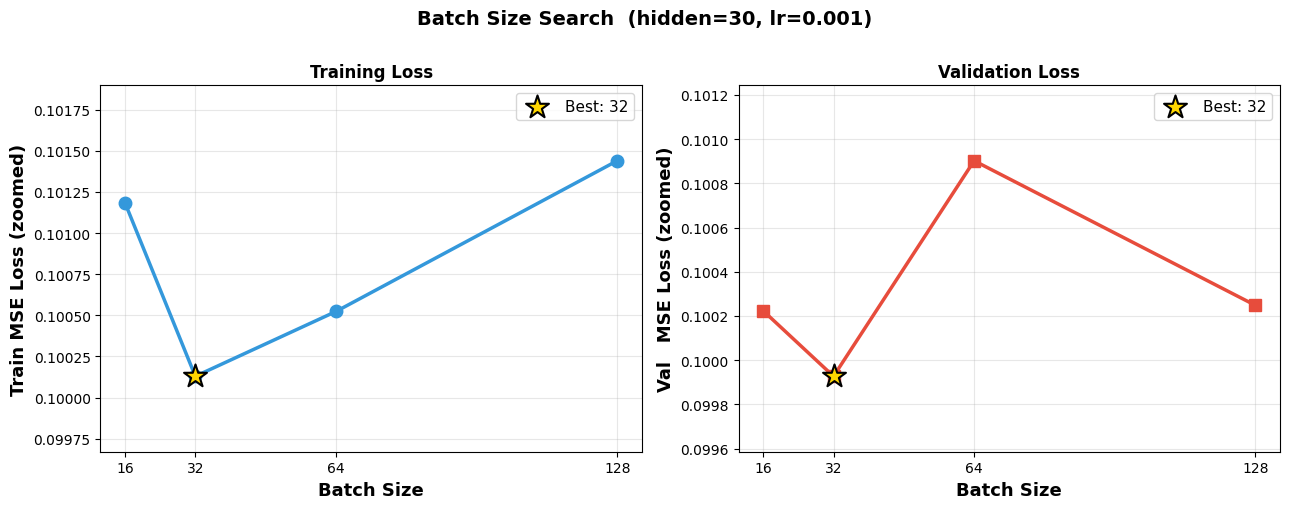

In [12]:
# ── Step 2: Search Batch Size ─────────────────────────────────────────────────
# Fixed: hidden=best_hs, lr=0.001
print("=" * 70)
print("STEP 2: BATCH SIZE SEARCH")
print("=" * 70)
print(f"Fixed → hidden={best_hs}, lr=0.001, max_epochs=100, patience=10")

batch_sizes = [16, 32, 64, 128]
FIXED_LR_BS = 0.001 

bs_results = []
for bs in tqdm(batch_sizes, desc="Batch size search"):
    train_loader_bs, val_loader_bs = make_loaders(X_train_scaled, y_train_scaled, bs)
    model, opt, crit = create_ann_model(input_dim, output_dim,
                                        hidden_neurons=best_hs, learning_rate=FIXED_LR_BS)
    best_val, best_train, epochs = train_with_early_stopping(
        model, opt, crit, train_loader_bs, val_loader_bs, max_epochs=100, patience=10)
    bs_results.append({'batch_size': bs, 'val_loss': best_val,
                       'train_loss': best_train, 'epochs': epochs})
    print(f"  batch={bs:3d}  train_loss={best_train:.6f}  val_loss={best_val:.6f}  epochs={epochs}")

best_bs      = min(bs_results, key=lambda r: r['val_loss'])['batch_size']
best_bs_loss = min(bs_results, key=lambda r: r['val_loss'])['val_loss']
print(f"\n✓ Best batch size: {best_bs}  (val_loss={best_bs_loss:.6f})")

zoomed_dual_plot(bs_results, 'batch_size', 'Batch Size',
                 f'Batch Size Search  (hidden={best_hs}, lr={FIXED_LR_BS})',
                 x_ticks=[r['batch_size'] for r in bs_results],
                 filename='search_batch_size.png')


STEP 3: LEARNING RATE SEARCH
Fixed → hidden=30, batch=32, max_epochs=150, patience=15


LR search:  25%|██▌       | 1/4 [00:52<02:38, 52.72s/it]

  lr=0.0010  train_loss=0.100808  val_loss=0.100342  epochs=82


LR search:  50%|█████     | 2/4 [01:26<01:23, 41.71s/it]

  lr=0.0020  train_loss=0.101375  val_loss=0.099904  epochs=56


LR search:  75%|███████▌  | 3/4 [02:10<00:42, 42.71s/it]

  lr=0.0030  train_loss=0.100669  val_loss=0.099560  epochs=71


LR search: 100%|██████████| 4/4 [02:58<00:00, 44.60s/it]

  lr=0.0050  train_loss=0.101222  val_loss=0.099101  epochs=82

✓ Best learning rate: 0.005  (val_loss=0.099101)


✓ Saved: results/5/search_learning_rate.png


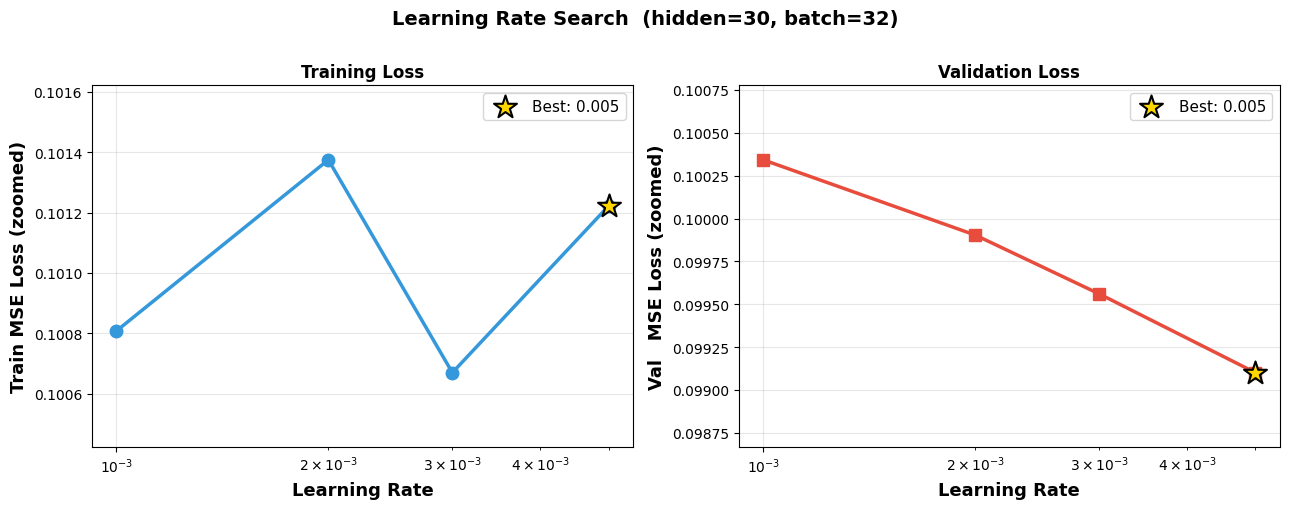

In [13]:
# ── Step 3: Search Learning Rate ─────────────────────────────────────────────
# Fixed: hidden=best_hs, batch=best_bs
print("=" * 70)
print("STEP 3: LEARNING RATE SEARCH")
print("=" * 70)
print(f"Fixed → hidden={best_hs}, batch={best_bs}, max_epochs=150, patience=15")

learning_rates = [0.001, 0.002, 0.003, 0.005]

train_loader_lr, val_loader_lr = make_loaders(X_train_scaled, y_train_scaled, best_bs)

lr_results = []
for lr in tqdm(learning_rates, desc="LR search"):
    model, opt, crit = create_ann_model(input_dim, output_dim,
                                        hidden_neurons=best_hs, learning_rate=lr)
    best_val, best_train, epochs = train_with_early_stopping(
        model, opt, crit, train_loader_lr, val_loader_lr, max_epochs=150, patience=15)
    lr_results.append({'lr': lr, 'val_loss': best_val,
                       'train_loss': best_train, 'epochs': epochs})
    print(f"  lr={lr:.4f}  train_loss={best_train:.6f}  val_loss={best_val:.6f}  epochs={epochs}")

best_lr      = min(lr_results, key=lambda r: r['val_loss'])['lr']
best_lr_loss = min(lr_results, key=lambda r: r['val_loss'])['val_loss']
print(f"\n✓ Best learning rate: {best_lr}  (val_loss={best_lr_loss:.6f})")

zoomed_dual_plot(lr_results, 'lr', 'Learning Rate',
                 f'Learning Rate Search  (hidden={best_hs}, batch={best_bs})',
                 log_x=True,
                 filename='search_learning_rate.png')

In [14]:
# ── Best Configuration Summary ────────────────────────────────────────────────
print("=" * 70)
print("BEST HYPERPARAMETER CONFIGURATION")
print("=" * 70)
print(f"  Hidden neurons : {best_hs}")
print(f"  Batch size     : {best_bs}")
print(f"  Learning rate  : {best_lr}")
print(f"  Val loss (LR step): {best_lr_loss:.6f}")
print("=" * 70)

BEST HYPERPARAMETER CONFIGURATION
  Hidden neurons : 30
  Batch size     : 32
  Learning rate  : 0.005
  Val loss (LR step): 0.099101


FINAL TRAINING
  Config → hidden=30, batch=32, lr=0.005
  max_epochs=200, patience=15


  Epoch   1  train=0.155174  val=0.111603
  Epoch  20  train=0.103708  val=0.103110
  Epoch  40  train=0.102448  val=0.099935
  Early stop at epoch 56  (best val @ epoch 41)

✓ Best val loss: 0.099359  at epoch 41
✓ Model saved: results/5/final_model_best.pth


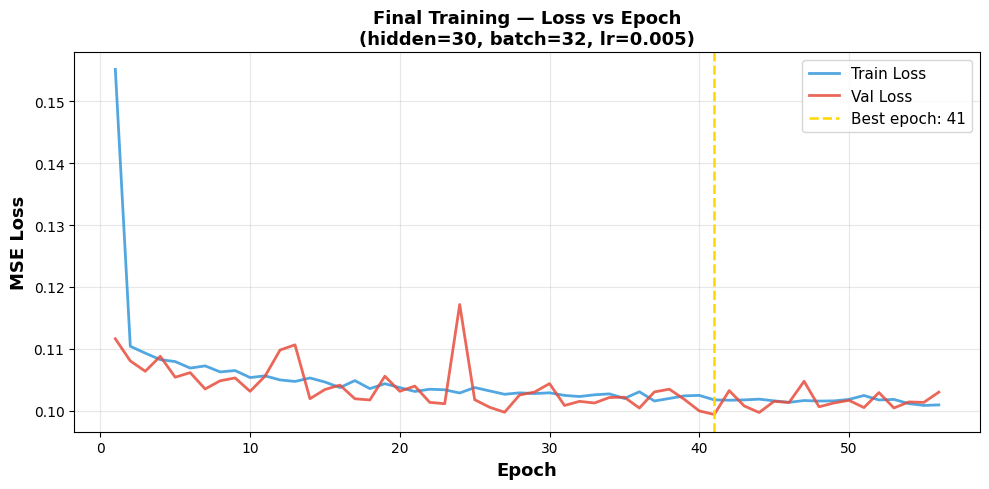

✓ Saved: results/5/final_training_loss.png


In [15]:
# ── Final Model Training ──────────────────────────────────────────────────────
print("=" * 70)
print("FINAL TRAINING")
print(f"  Config → hidden={best_hs}, batch={best_bs}, lr={best_lr}")
print(f"  max_epochs=200, patience=15")
print("=" * 70)

MAX_EPOCHS = 200
PATIENCE   = 15

# Fresh model + loaders (80/20 train/val split on all training data)
final_model, final_opt, final_crit = create_ann_model(
    input_dim, output_dim, hidden_neurons=best_hs, learning_rate=best_lr)
train_loader_final, val_loader_final = make_loaders(
    X_train_scaled, y_train_scaled, best_bs, val_frac=0.2, seed=42)

# Training loop — record per-epoch losses
train_loss_history = []
val_loss_history   = []
best_val_final     = float('inf')
best_epoch_final   = 0
patience_counter   = 0
best_state_final   = copy.deepcopy(final_model.state_dict())

for epoch in range(MAX_EPOCHS):
    # ── train
    final_model.train()
    batch_losses = []
    for Xb, yb in train_loader_final:
        Xb, yb = Xb.to(device), yb.to(device)
        final_opt.zero_grad()
        loss = final_crit(final_model(Xb), yb)
        loss.backward()
        final_opt.step()
        batch_losses.append(loss.item())
    avg_train = float(np.mean(batch_losses))

    # ── validate
    final_model.eval()
    val_losses = []
    with torch.no_grad():
        for Xb, yb in val_loader_final:
            val_losses.append(final_crit(final_model(Xb.to(device)), yb.to(device)).item())
    avg_val = float(np.mean(val_losses))

    train_loss_history.append(avg_train)
    val_loss_history.append(avg_val)

    if avg_val < best_val_final:
        best_val_final   = avg_val
        best_epoch_final = epoch
        patience_counter = 0
        best_state_final = copy.deepcopy(final_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}  (best val @ epoch {best_epoch_final+1})")
            break

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}  train={avg_train:.6f}  val={avg_val:.6f}")

final_model.load_state_dict(best_state_final)
print(f"\n✓ Best val loss: {best_val_final:.6f}  at epoch {best_epoch_final+1}")

# ── Save model
model_path = f'{OUTPUT_DIR}/final_model_best.pth'
torch.save({'model_state_dict': final_model.state_dict(),
            'best_hs': best_hs, 'best_bs': best_bs, 'best_lr': best_lr,
            'val_loss': best_val_final, 'epoch': best_epoch_final}, model_path)
print(f"✓ Model saved: {model_path}")

# ── Loss vs Epoch plot
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, label='Train Loss', color='#3498DB',
        linewidth=2, alpha=0.85)
ax.plot(epochs_range, val_loss_history,   label='Val Loss',   color='#E74C3C',
        linewidth=2, alpha=0.85)
ax.axvline(best_epoch_final + 1, color='gold', linestyle='--', linewidth=1.8,
           label=f'Best epoch: {best_epoch_final+1}')
ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
ax.set_title(f'Final Training — Loss vs Epoch\n'
             f'(hidden={best_hs}, batch={best_bs}, lr={best_lr})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/final_training_loss.png")

MODEL EVALUATION — TEST SET

Metric                               Value
---------------------------------------------
MAE  (log10 units)                0.291961
MSE  (log10 units)                0.141854
RMSE (log10 units)                0.376636
R²   (overall)                    0.900895
MAPE (original units, %)           93.9935
---------------------------------------------

  Mean R²  across 92 outputs : 0.900895
  Min  R²                         : 0.866214  (output #24  →  log10_T0.080S)
  Max  R²                         : 0.940870
  Mean MAE across 92 outputs : 0.291961
  Mean RMSE                       : 0.376040


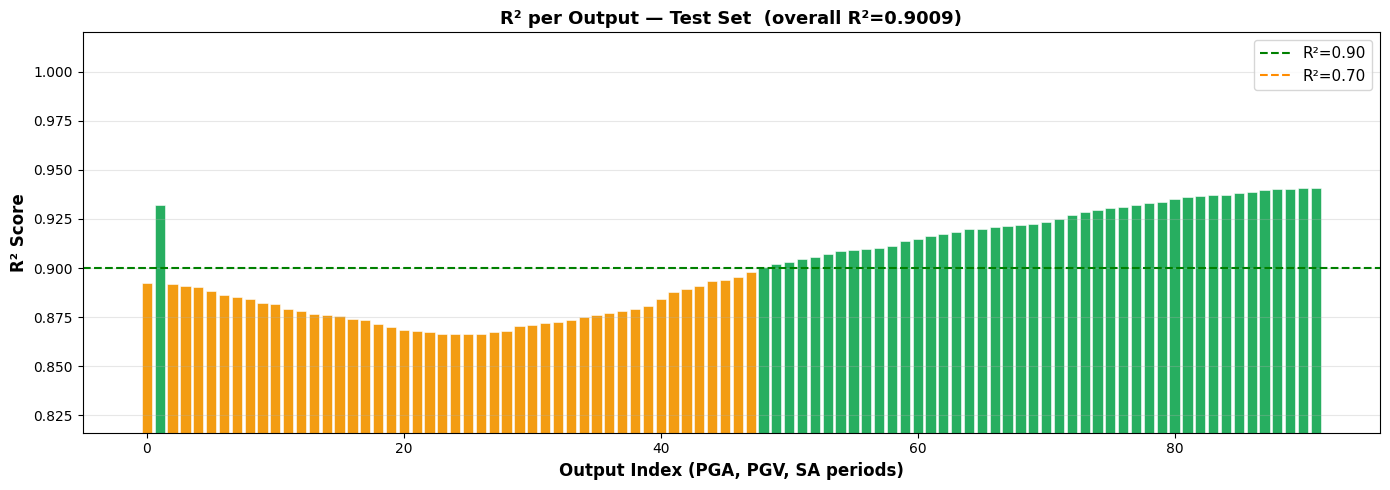

✓ Saved: results/5/eval_r2_per_output.png


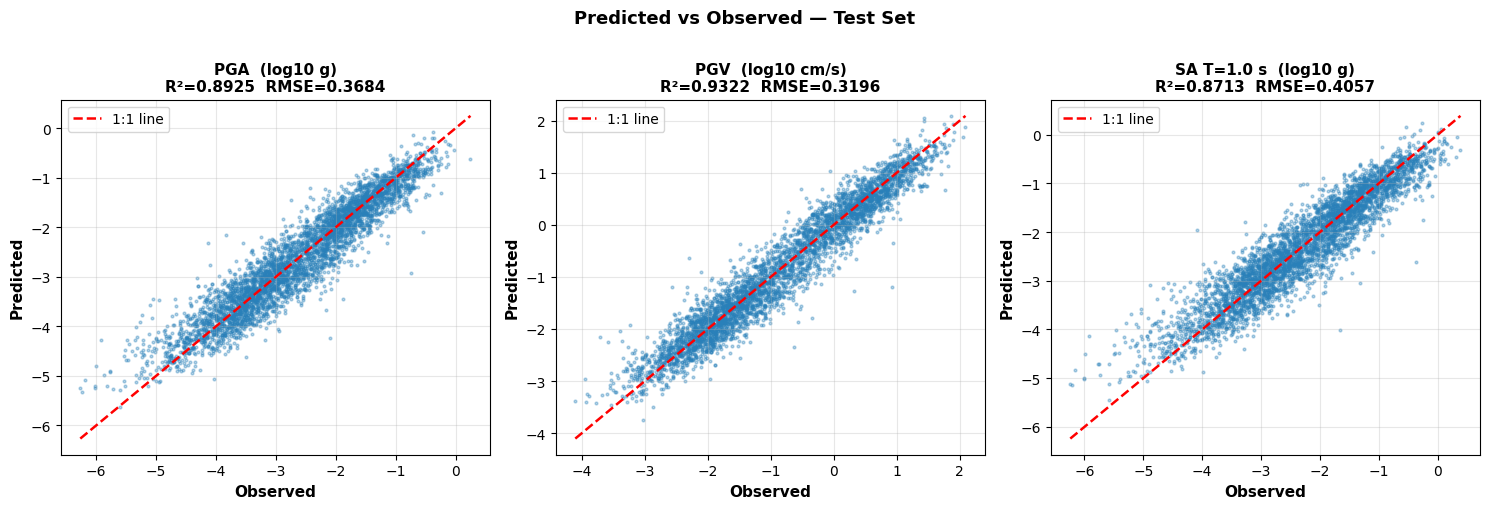

✓ Saved: results/5/eval_pred_vs_obs.png


In [ ]:
# ── Model Evaluation on Test Set ─────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("MODEL EVALUATION — TEST SET")
print("=" * 70)

# ── Predictions (standardized space → original log10 space → 10^x space)
y_pred_scaled = get_predictions(final_model, X_test_tensor)   # shape (N, output_dim)
y_pred_log    = scaler_y.inverse_transform(y_pred_scaled)     # back to log10 scale
y_true_log    = scaler_y.inverse_transform(y_test_scaled)     # back to log10 scale
y_pred_orig   = 10 ** y_pred_log                              # original units
y_true_orig   = 10 ** y_true_log                              # original units

# ── Calculate residuals (for later use in residual analysis)
residuals = y_true_log - y_pred_log                            # residuals in log10 space

# ── Per-output metrics (in log10 space — dimensionless, standard for GMMs)
r2_per_output   = [r2_score(y_true_log[:, i], y_pred_log[:, i])
                   for i in range(output_dim)]
mae_per_output  = [mean_absolute_error(y_true_log[:, i], y_pred_log[:, i])
                   for i in range(output_dim)]
rmse_per_output = [np.sqrt(mean_squared_error(y_true_log[:, i], y_pred_log[:, i]))
                   for i in range(output_dim)]

# ── Overall (mean across all output targets, in log10 space)
mae_overall  = mean_absolute_error(y_true_log,  y_pred_log)
mse_overall  = mean_squared_error(y_true_log,   y_pred_log)
rmse_overall = np.sqrt(mse_overall)
r2_overall   = r2_score(y_true_log, y_pred_log)

# ── MAPE in original space (%)
mape_overall = float(np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-12))) * 100)

print(f"\n{'Metric':<28}  {'Value':>12}")
print("-" * 45)
print(f"{'MAE  (log10 units)':<28}  {mae_overall:>12.6f}")
print(f"{'MSE  (log10 units)':<28}  {mse_overall:>12.6f}")
print(f"{'RMSE (log10 units)':<28}  {rmse_overall:>12.6f}")
print(f"{'R²   (overall)':<28}  {r2_overall:>12.6f}")
print(f"{'MAPE (original units, %)':<28}  {mape_overall:>12.4f}")
print("-" * 45)
print(f"\n  Mean R²  across {output_dim} outputs : {np.mean(r2_per_output):.6f}")
print(f"  Min  R²                         : {np.min(r2_per_output):.6f}  "
      f"(output #{np.argmin(r2_per_output)}  →  {output_target_cols[np.argmin(r2_per_output)]})")
print(f"  Max  R²                         : {np.max(r2_per_output):.6f}")
print(f"  Mean MAE across {output_dim} outputs : {np.mean(mae_per_output):.6f}")
print(f"  Mean RMSE                       : {np.mean(rmse_per_output):.6f}")

# ── Plot 1: R² per output (bar)
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#27AE60' if v >= 0.9 else '#F39C12' if v >= 0.7 else '#E74C3C'
          for v in r2_per_output]
ax.bar(range(output_dim), r2_per_output, color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(0.9, color='green',      linestyle='--', linewidth=1.5, label='R²=0.90')
ax.axhline(0.7, color='darkorange', linestyle='--', linewidth=1.5, label='R²=0.70')
ax.set_xlabel('Output Index (PGA, PGV, SA periods)', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title(f'R² per Output — Test Set  (overall R²={r2_overall:.4f})',
             fontsize=13, fontweight='bold')
ax.set_ylim(max(0, min(r2_per_output) - 0.05), 1.02)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eval_r2_per_output.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/eval_r2_per_output.png")

# ── Plot 2: Predicted vs Actual scatter (PGA — output index 0)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['PGA  (log10 g)', 'PGV  (log10 cm/s)', 'SA T=1.0 s  (log10 g)']
idx_sa1 = output_target_cols.index('log10_Sa_T1.000S') if 'log10_Sa_T1.000S' in output_target_cols else min(output_dim - 1, 30)
plot_indices = [0, 1, idx_sa1]

for ax_i, (ax, idx, title) in enumerate(zip(axes, plot_indices, titles)):
    lo = min(y_true_log[:, idx].min(), y_pred_log[:, idx].min())
    hi = max(y_true_log[:, idx].max(), y_pred_log[:, idx].max())
    ax.scatter(y_true_log[:, idx], y_pred_log[:, idx],
               s=4, alpha=0.35, color='#2980B9', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='1:1 line')
    ax.set_xlabel('Observed', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nR²={r2_per_output[idx]:.4f}  RMSE={rmse_per_output[idx]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Observed — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eval_pred_vs_obs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/eval_pred_vs_obs.png")

In [17]:
# ── Residual Analysis  ────────────────────────────────────────────────────────
# Residual = log10(Observed) – log10(Predicted)
# Positive → under-prediction  |  Negative → over-prediction

# ── Extract PGA residuals and conditioning variables ──────────────────────────
pga_resid = residuals[:, 0]          # index 0 = log10_PGA

idx_mag  = input_feature_cols.index('Earthquake Magnitude')
idx_rjb  = input_feature_cols.index('Joyner-Boore Dist. (km)')
idx_vs30 = input_feature_cols.index('Vs30 (m/s) selected for analysis')

Mw   = X_test[:, idx_mag ].astype(float)
Rjb  = X_test[:, idx_rjb ].astype(float)
Vs30 = X_test[:, idx_vs30].astype(float)

# ── Equal-count binning ───────────────────────────────────────────────────────
def equal_count_bins(x, y, n_bins=10, log_x=False):
    """
    Sort x, split into n_bins equal-count groups.
    Returns (centers, means, stds, counts).
    center = geometric mean when log_x=True, arithmetic mean otherwise.
    """
    order  = np.argsort(x)
    xs, ys = x[order], y[order]
    groups = np.array_split(np.arange(len(xs)), n_bins)
    centers, means, stds, counts = [], [], [], []
    for g in groups:
        if len(g) < 2:
            continue
        xg, yg = xs[g], ys[g]
        c = np.exp(np.mean(np.log(np.clip(xg, 1e-9, None)))) if log_x else np.mean(xg)
        centers.append(c)
        means.append(np.mean(yg))
        stds.append(np.std(yg, ddof=1))
        counts.append(len(g))
    return np.array(centers), np.array(means), np.array(stds), np.array(counts)

# ── Generic plot function ─────────────────────────────────────────────────────
def residual_plot(x, y, xlabel, title, filename,
                  log_x=False, n_bins=10, ylim=(-1.0, 1.0)):
    """
    Scatter + binned-mean residual plot matching reference style:
      • green open circles  (scatter)
      • red diamonds        (bin mean)
      • blue error bars     (± 1σ)
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    # ── scatter: green open circles, clearly visible
    ax.scatter(x, y,
               s=12, facecolors='none', edgecolors='#22AA22',
               linewidths=0.8, alpha=0.55, rasterized=True,
               zorder=2, label='Residual')

    # ── zero reference line
    ax.axhline(0.0, color='black', linewidth=1.2, linestyle='-', zorder=3)

    # ── bins: red diamonds + blue error bars
    bc, bm, bs, bn = equal_count_bins(x, y, n_bins=n_bins, log_x=log_x)
    ax.errorbar(bc, bm,
                yerr=bs,
                fmt='D',                      # diamond marker
                color="#D13434",              # red fill
                ecolor="#000000",             # blue error bars
                elinewidth=2.0,
                capsize=5,
                capthick=2.0,
                markersize=9,
                markeredgecolor="#060606",
                markeredgewidth=0.8,
                linewidth=0,
                zorder=5,
                label='Mean')

    if log_x:
        ax.set_xscale('log')

    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel,          fontsize=12, fontweight='bold')
    ax.set_ylabel('Residual',      fontsize=12, fontweight='bold')
    ax.set_title(f'PGA\n{title}',  fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, framealpha=0.9,
              loc='upper right' if log_x else 'upper left')
    ax.grid(True, which='both' if log_x else 'major',
            linestyle='-', linewidth=0.6, alpha=0.45, color='#CCCCCC')
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {OUTPUT_DIR}/{filename}")


# ── Figure 1 — PGA vs Magnitude ───────────────────────────────────────────────
residual_plot(Mw, pga_resid,
              xlabel='Magnitude',
              title='Inter-Event Residual',
              filename='residuals_PGA_vs_magnitude.png',
              log_x=False, n_bins=10, ylim=(-1.6, 1.6))

# ── Figure 2 — PGA vs Rjb (distance) ──────────────────────────────────────────
mask = Rjb > 0.1
residual_plot(Rjb[mask], pga_resid[mask],
              xlabel='Closest distance to Rupture, $R_{rup}$ (km)',
              title='Intra-Event Residual (Measured $V_{S30}$)',
              filename='residuals_PGA_vs_distance.png',
              log_x=False, n_bins=10, ylim=(-1.6, 1.6))

# ── Figure 3 — PGA vs Vs30 ────────────────────────────────────────────────────
residual_plot(Vs30, pga_resid,
              xlabel='Shear wave velocity, $V_{S30}$ (m/s)',
              title='Intra-Event Residual (Measured $V_{S30}$)',
              filename='residuals_PGA_vs_vs30.png',
              log_x=False, n_bins=10, ylim=(-1.6, 1.6))

NameError: name 'residuals' is not defined

PHASE 5: PARAMETRIC STUDY - RESPONSE SPECTRA

PHASE 5.1: PARAMETRIC STUDY - MAGNITUDE VARIATION
  Fixed: Rjb=10.0 km, Vs30=760.0 m/s, Mechanism=1
  Mw variations: [4.0, 5.0, 6.0, 7.0, 7.5]


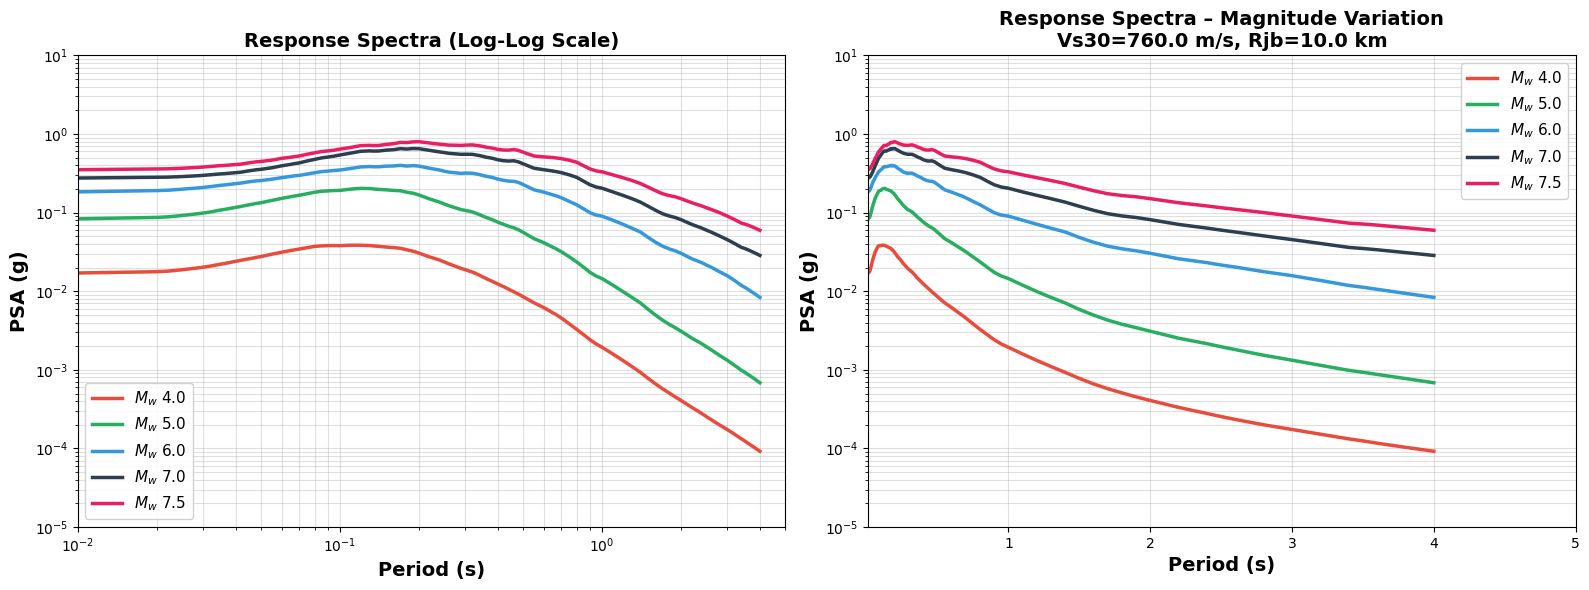

✓ Saved: results/5/parametric_magnitude.png

PHASE 5.2: PARAMETRIC STUDY - DISTANCE VARIATION
  Fixed: Mw=7.0, Vs30=760.0 m/s, Mechanism=1
  Rjb variations: [10.0, 22.36, 50.0, 111.8, 250.0] km


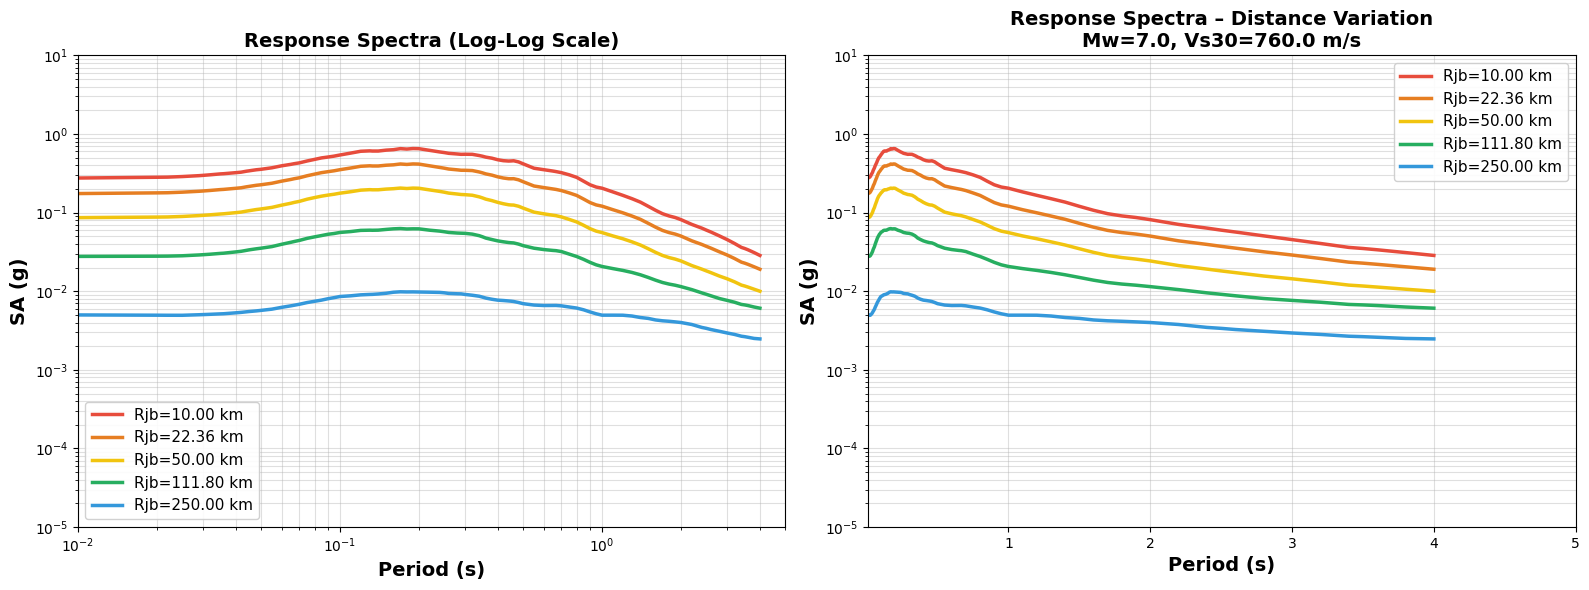

✓ Saved: results/5/parametric_distance.png

PHASE 5.3: PARAMETRIC STUDY - SITE CONDITION (Vs30) VARIATION
  Fixed: Mw=6.5, Rjb=10.0 km, Mechanism=1
  Vs30 variations: [1500, 760, 525, 225, 150] m/s


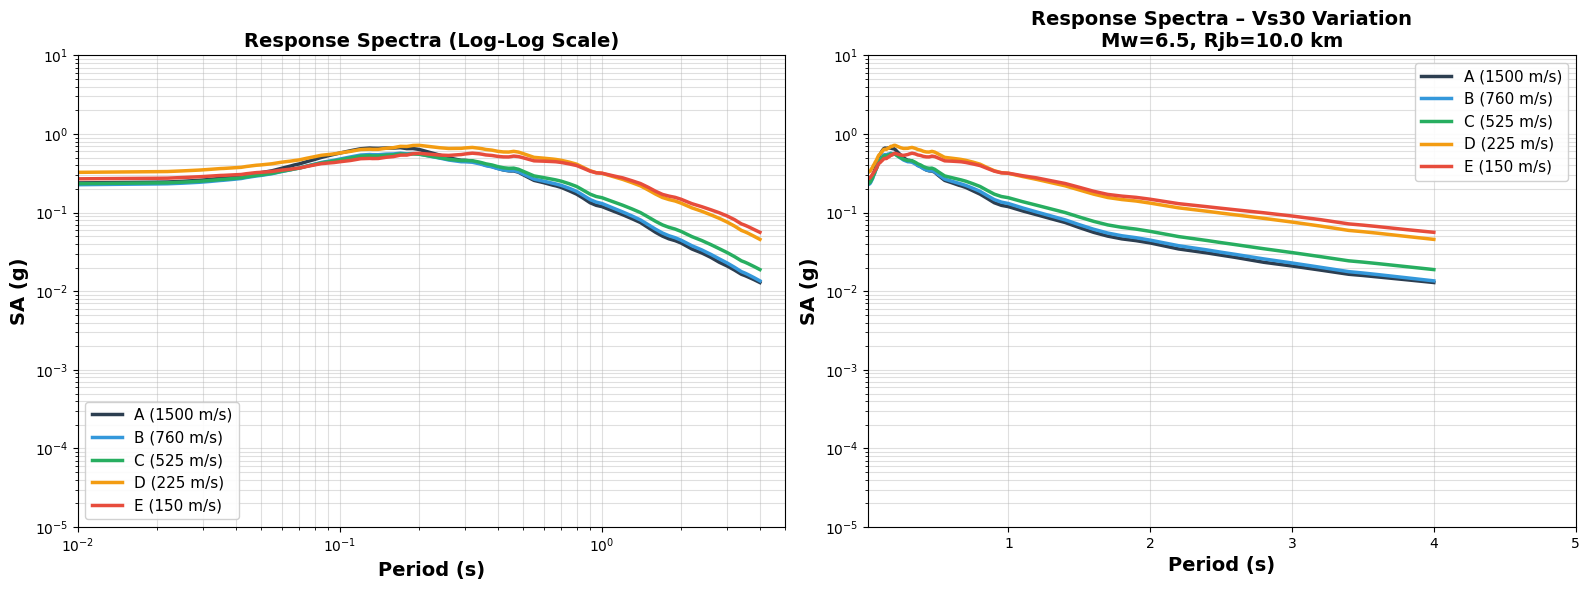

✓ Saved: results/5/parametric_vs30.png

✓ PHASE 5 COMPLETE: All parametric studies done
  Saved to: results/5/


In [ ]:

# Phase 5: Parametric Study – Response Spectra
print("="*80)
print("PHASE 5: PARAMETRIC STUDY - RESPONSE SPECTRA")
print("="*80)

import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Define sa_periods from selected_period_cols_sorted ───────────────────────
def period_to_float(col_name):
    """Convert 'T0.010S' to 0.010"""
    return float(col_name[1:-1])

sa_periods = np.array([period_to_float(col) for col in selected_period_cols_sorted])
print(f"  SA periods defined: {len(sa_periods)} periods from {sa_periods[0]:.3f}s to {sa_periods[-1]:.3f}s")

# Feature order: ['Earthquake Magnitude', 'Joyner-Boore Dist. (km)',
#                 'Mechanism Based on Rake Angle',
#                 'Vs30 (m/s) selected for analysis', 'log10_Vs30', 'log10_Rjb']
def predict_spectrum(Mw, Rjb, mechanism, Vs30):
    """Return SA spectrum (g) for the given source/path/site parameters."""
    X_raw = np.array([[Mw, Rjb, mechanism, Vs30, np.log10(Vs30), np.log10(Rjb)]])
    X_scaled = scaler_X.transform(X_raw)
    X_tensor = torch.FloatTensor(X_scaled).to(device)
    final_model.eval()
    with torch.no_grad():
        y_scaled = final_model(X_tensor).cpu().numpy()
    y_log = scaler_y.inverse_transform(y_scaled)
    y_lin = 10 ** y_log
    return y_lin[0, 2:]   # Skip PGA (idx 0) and PGV (idx 1)

# ─────────────────────────────────────────────────────────────────────────────
# 5.1 Magnitude Variation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("PHASE 5.1: PARAMETRIC STUDY - MAGNITUDE VARIATION")
print("="*80)

fixed_rjb  = 10.0    # km
fixed_vs30 = 760.0   # m/s  (NEHRP B/C boundary – rock site)
fixed_mech = 1       # strike-slip

magnitudes  = [4.0, 5.0, 6.0, 7.0, 7.5]
colors_mag  = ['#E74C3C', '#27AE60', '#3498DB', '#2C3E50', '#E91E63']

print(f"  Fixed: Rjb={fixed_rjb} km, Vs30={fixed_vs30} m/s, Mechanism={fixed_mech}")
print(f"  Mw variations: {magnitudes}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for mag, color in zip(magnitudes, colors_mag):
    sa = predict_spectrum(mag, fixed_rjb, fixed_mech, fixed_vs30)
    ax1.loglog(sa_periods, sa, '-', linewidth=2.5, label=f'$M_w$ {mag}', color=color)
    ax2.semilogy(sa_periods, sa, '-', linewidth=2.5, label=f'$M_w$ {mag}', color=color)

for ax in (ax1, ax2):
    ax.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
    ax.set_ylabel('PSA (g)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.4, which='both')
    ax.set_xlim(0.01, 5)

ax1.set_title('Response Spectra (Log-Log Scale)', fontsize=14, fontweight='bold')
ax1.set_ylim(1e-5, 10)
ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)

ax2.set_title(f'Response Spectra – Magnitude Variation\nVs30={fixed_vs30} m/s, Rjb={fixed_rjb} km',
              fontsize=14, fontweight='bold')
ax2.set_ylim(1e-5, 10)
ax2.legend(fontsize=11, loc='upper right', framealpha=0.9)

plt.tight_layout()
plot_path_mag = os.path.join(OUTPUT_DIR, 'parametric_magnitude.png')
plt.savefig(plot_path_mag, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {plot_path_mag}")

# ─────────────────────────────────────────────────────────────────────────────
# 5.2 Distance (Rjb) Variation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("PHASE 5.2: PARAMETRIC STUDY - DISTANCE VARIATION")
print("="*80)

fixed_mag_dist = 7.0   # Mw

distances  = [10.0, 22.36, 50.0, 111.80, 250.0]   # km
colors_dist = ['#E74C3C', '#E67E22', '#F1C40F', '#27AE60', '#3498DB']

print(f"  Fixed: Mw={fixed_mag_dist}, Vs30={fixed_vs30} m/s, Mechanism={fixed_mech}")
print(f"  Rjb variations: {distances} km")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for rjb, color in zip(distances, colors_dist):
    sa = predict_spectrum(fixed_mag_dist, rjb, fixed_mech, fixed_vs30)
    ax1.loglog(sa_periods, sa, '-', linewidth=2.5, label=f'Rjb={rjb:.2f} km', color=color)
    ax2.semilogy(sa_periods, sa, '-', linewidth=2.5, label=f'Rjb={rjb:.2f} km', color=color)

for ax in (ax1, ax2):
    ax.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
    ax.set_ylabel('SA (g)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.4, which='both')
    ax.set_xlim(0.01, 5)

ax1.set_title('Response Spectra (Log-Log Scale)', fontsize=14, fontweight='bold')
ax1.set_ylim(1e-5, 10)
ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)

ax2.set_title(f'Response Spectra – Distance Variation\nMw={fixed_mag_dist}, Vs30={fixed_vs30} m/s',
              fontsize=14, fontweight='bold')
ax2.set_ylim(1e-5, 10)
ax2.legend(fontsize=11, loc='upper right', framealpha=0.9)

plt.tight_layout()
plot_path_dist = os.path.join(OUTPUT_DIR, 'parametric_distance.png')
plt.savefig(plot_path_dist, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {plot_path_dist}")

# ─────────────────────────────────────────────────────────────────────────────
# 5.3 Vs30 (Site Class) Variation
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("PHASE 5.3: PARAMETRIC STUDY - SITE CONDITION (Vs30) VARIATION")
print("="*80)

fixed_mag_vs30 = 6.5
fixed_rjb_vs30 = 10.0   # km

vs30_values = [1500, 760, 525, 225, 150]
vs30_labels = ['A (1500 m/s)', 'B (760 m/s)', 'C (525 m/s)', 'D (225 m/s)', 'E (150 m/s)']
colors_vs30 = ['#2C3E50', '#3498DB', '#27AE60', '#F39C12', '#E74C3C']

print(f"  Fixed: Mw={fixed_mag_vs30}, Rjb={fixed_rjb_vs30} km, Mechanism={fixed_mech}")
print(f"  Vs30 variations: {vs30_values} m/s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for vs30, label, color in zip(vs30_values, vs30_labels, colors_vs30):
    sa = predict_spectrum(fixed_mag_vs30, fixed_rjb_vs30, fixed_mech, vs30)
    ax1.loglog(sa_periods, sa, '-', linewidth=2.5, label=label, color=color)
    ax2.semilogy(sa_periods, sa, '-', linewidth=2.5, label=label, color=color)

for ax in (ax1, ax2):
    ax.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
    ax.set_ylabel('SA (g)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.4, which='both')
    ax.set_xlim(0.01, 5)

ax1.set_title('Response Spectra (Log-Log Scale)', fontsize=14, fontweight='bold')
ax1.set_ylim(1e-5, 10)
ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)

ax2.set_title(f'Response Spectra – Vs30 Variation\nMw={fixed_mag_vs30}, Rjb={fixed_rjb_vs30} km',
              fontsize=14, fontweight='bold')
ax2.set_ylim(1e-5, 10)
ax2.legend(fontsize=11, loc='upper right', framealpha=0.9)

plt.tight_layout()
plot_path_vs30 = os.path.join(OUTPUT_DIR, 'parametric_vs30.png')
plt.savefig(plot_path_vs30, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {plot_path_vs30}")

print(f"\n{'='*80}")
print("✓ PHASE 5 COMPLETE: All parametric studies done")
print(f"  Saved to: {OUTPUT_DIR}/")
print(f"{'='*80}")


PHASE 6: SHAP ANALYSIS & FEATURE IMPORTANCE
  shap version: 0.50.0

  Background samples : 300
  Explain  samples   : 500

  Computing SHAP values via DeepExplainer …
  ✓ SHAP computed — 92 output arrays, each (500, 6)

PHASE 6.1: GLOBAL FEATURE IMPORTANCE


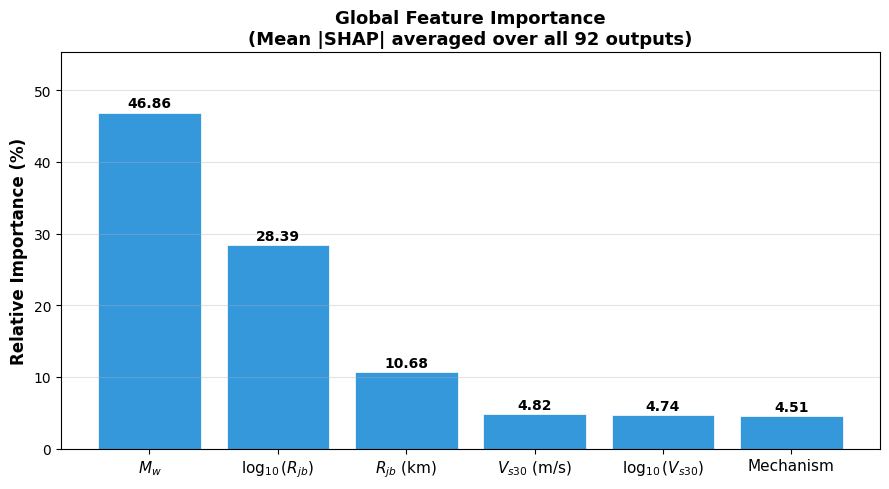

✓ Saved: results/5/shap_feature_importance.png

  Ranking:
    1. $M_w$                           46.86%
    2. $\log_{10}(R_{jb})$             28.39%
    3. $R_{jb}$ (km)                   10.68%
    4. $V_{s30}$ (m/s)                 4.82%
    5. $\log_{10}(V_{s30})$            4.74%
    6. Mechanism                       4.51%

PHASE 6.2: PER-OUTPUT SHAP BEESWARM PLOTS
  Panels: PGA(0), PGV(1), SA@0.2s(out#39), SA@1.0s(out#69)


/tmp/ipykernel_60816/3107680433.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_60816/3107680433.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_60816/3107680433.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_60816/3107680433.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this func

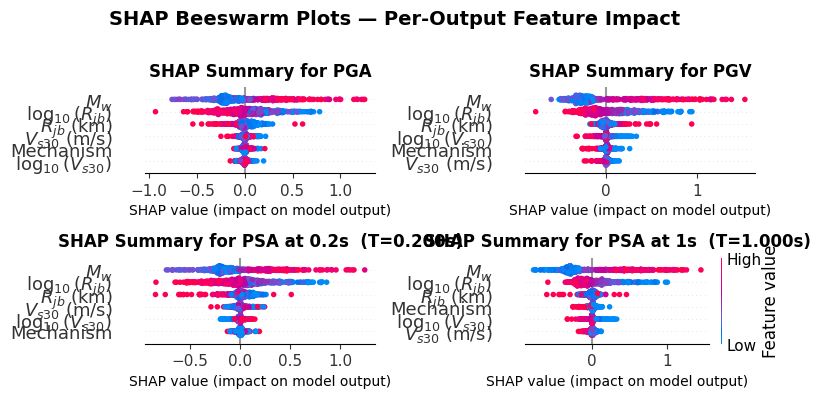

✓ Saved: results/5/shap_beeswarm_4panel.png

✓ PHASE 6 COMPLETE: SHAP Analysis & Feature Importance done
  Plots saved to: results/5/


In [ ]:
# Phase 6: SHAP Analysis & Feature Importance
import subprocess, sys
try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch

print("="*80)
print("PHASE 6: SHAP ANALYSIS & FEATURE IMPORTANCE")
print("="*80)
print(f"  shap version: {shap.__version__}")

# ── Feature display names (matching input_feature_cols order) ─────────────────
feature_names = [
    '$M_w$',
    '$R_{jb}$ (km)',
    'Mechanism',
    '$V_{s30}$ (m/s)',
    '$\\log_{10}(V_{s30})$',
    '$\\log_{10}(R_{jb})$',
]

# ── Background: 300 random training samples ───────────────────────────────────
np.random.seed(42)
bg_idx  = np.random.choice(len(X_train_scaled), 300, replace=False)
exp_idx = np.random.choice(len(X_test_scaled),  500, replace=False)

background = torch.tensor(X_train_scaled[bg_idx],  dtype=torch.float32).to(device)
X_exp_t    = torch.tensor(X_test_scaled[exp_idx],  dtype=torch.float32).to(device)
X_exp_np   = X_test_scaled[exp_idx]          # numpy for summary_plot

print(f"\n  Background samples : {len(bg_idx)}")
print(f"  Explain  samples   : {len(exp_idx)}")
print("\n  Computing SHAP values via DeepExplainer …")

final_model.eval()
explainer   = shap.DeepExplainer(final_model, background)
# check_additivity=False: needed for models with Dropout — the mask
# makes the exact Taylor decomposition slightly non-additive numerically.
shap_values = explainer.shap_values(X_exp_t, check_additivity=False)

# Normalise to a list: one (n_samples, n_features) array per output
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
elif isinstance(shap_values, list):
    shap_list = shap_values
else:
    raise ValueError(f"Unexpected shap_values type: {type(shap_values)}, shape: {np.array(shap_values).shape}")

print(f"  ✓ SHAP computed — {len(shap_list)} output arrays, each {shap_list[0].shape}")


PHASE 6.1: GLOBAL FEATURE IMPORTANCE


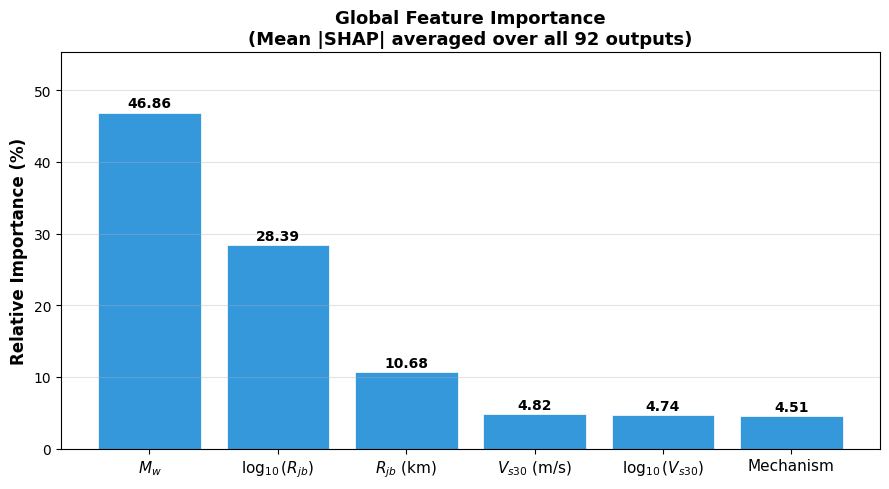

✓ Saved: results/5/shap_feature_importance.png

  Ranking:
    1. $M_w$                           46.86%
    2. $\log_{10}(R_{jb})$             28.39%
    3. $R_{jb}$ (km)                   10.68%
    4. $V_{s30}$ (m/s)                 4.82%
    5. $\log_{10}(V_{s30})$            4.74%
    6. Mechanism                       4.51%


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 6.1 Global Feature Importance bar chart
#     Metric: mean(|SHAP|) per feature, averaged over ALL 92 outputs, as %
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("PHASE 6.1: GLOBAL FEATURE IMPORTANCE")
print("="*80)

per_feat       = np.mean([np.abs(sv).mean(axis=0) for sv in shap_list], axis=0)
importance_pct = per_feat / per_feat.sum() * 100

# Sort descending
order              = np.argsort(importance_pct)[::-1]
feat_labels_sorted = [feature_names[i] for i in order]
importance_sorted  = importance_pct[order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(feature_names)), importance_sorted,
              color='#3498DB', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feat_labels_sorted, fontsize=11)
ax.set_ylabel('Relative Importance (%)', fontsize=12, fontweight='bold')
ax.set_title('Global Feature Importance\n(Mean |SHAP| averaged over all 92 outputs)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, importance_sorted[0] * 1.18)
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_feature_importance.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/shap_feature_importance.png")

print("\n  Ranking:")
for rank, (name, pct) in enumerate(zip(feat_labels_sorted, importance_sorted), 1):
    print(f"    {rank}. {name:<30s}  {pct:.2f}%")

/tmp/ipykernel_60816/2621393308.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


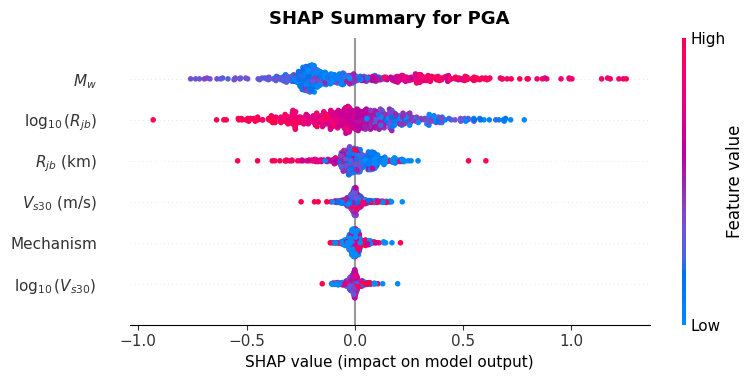

✓ Saved: results/5/shap_beeswarm_PGA.png


/tmp/ipykernel_60816/2621393308.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


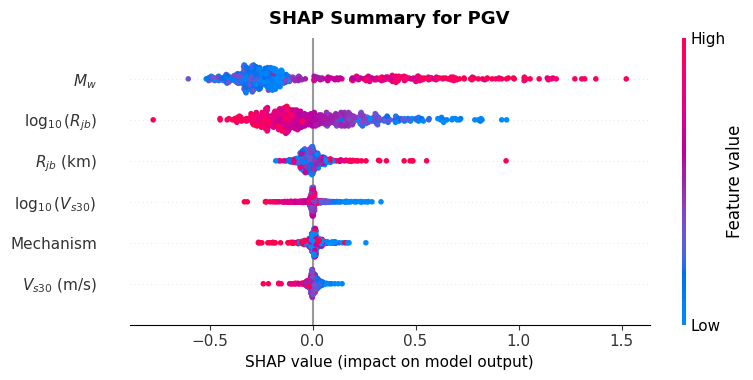

✓ Saved: results/5/shap_beeswarm_PGV.png


/tmp/ipykernel_60816/2621393308.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


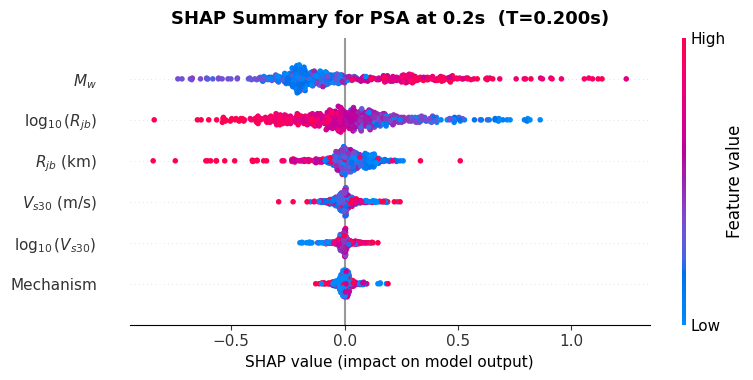

✓ Saved: results/5/shap_beeswarm_SA0.2s.png


/tmp/ipykernel_60816/2621393308.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


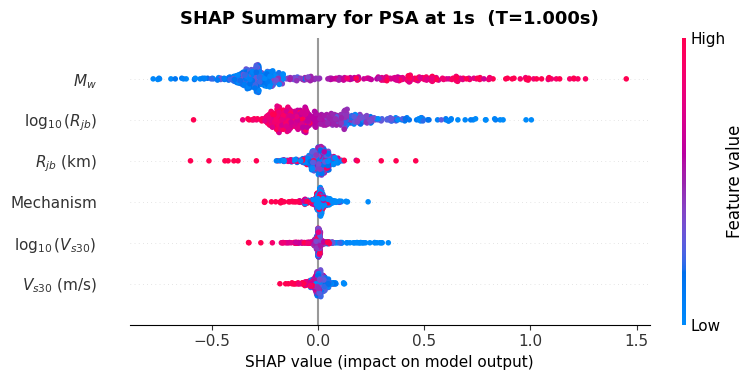

✓ Saved: results/5/shap_beeswarm_SA1.0s.png


In [ ]:
# Phase 6.3: Separate SHAP beeswarm figures — one per output
# Reuses shap_list, X_exp_np, feature_names already in memory

import matplotlib.pyplot as plt

# ── Find indices for specific periods (0.2s and 1.0s) ────────────────────────
idx_02s = np.argmin(np.abs(sa_periods - 0.2)) + 2    # +2 because PGA and PGV come first
idx_10s = np.argmin(np.abs(sa_periods - 1.0)) + 2    # +2 because PGA and PGV come first
print(f"  T=0.2s → output index {idx_02s}  (actual T={sa_periods[idx_02s-2]:.3f}s)")
print(f"  T=1.0s → output index {idx_10s}  (actual T={sa_periods[idx_10s-2]:.3f}s)")

panels = [
    (0,       'SHAP Summary for PGA',
              f'{OUTPUT_DIR}/shap_beeswarm_PGA.png'),
    (1,       'SHAP Summary for PGV',
              f'{OUTPUT_DIR}/shap_beeswarm_PGV.png'),
    (idx_02s, f'SHAP Summary for PSA at 0.2s  (T={sa_periods[idx_02s-2]:.3f}s)',
              f'{OUTPUT_DIR}/shap_beeswarm_SA0.2s.png'),
    (idx_10s, f'SHAP Summary for PSA at 1s  (T={sa_periods[idx_10s-2]:.3f}s)',
              f'{OUTPUT_DIR}/shap_beeswarm_SA1.0s.png'),
]

for out_idx, title, fpath in panels:
    fig, ax = plt.subplots(figsize=(9, 5))
    plt.sca(ax)
    shap.summary_plot(
        shap_list[out_idx],
        X_exp_np,
        feature_names=feature_names,
        plot_type='dot',
        show=False,
        color_bar=True,
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('SHAP value (impact on model output)', fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    plt.tight_layout()
    plt.savefig(fpath, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✓ Saved: {fpath}")
